Downscaling to be further checked. 

Possible issues found:
- length matrix with non zero values on the diagonal (e.g. ca1-ca1 length higher than ca1-ca2 length)
- gdist shorter than length (one is across the surface, one along the white fibers tracts respectively)
- weights non-matching with the circle shown above (e.g. ca1 more connected to parahippocampus than enthorinal cortex)

## Simulation

Ingredients:
- model : Field Epileptor Model 
- connectivity : weights and lengths as computed above
- local connectivity : using gdists as above (missing area-scaling?) + Heaviside coupling
- integrator : euler deterministic
- monitors : Raw or temporal average


# Load libraries and data

## Load libraries

In [24]:
#---------------------
# Importing libraries
#---------------------

import numpy as np                             # np
from pathlib import Path                       # Path
from matplotlib import pyplot as plt           # plt
from scipy.sparse import load_npz              # For Loading npz

# TVB stuff
from tvb.simulator.lab import integrators, monitors, connectivity

# Freesurfer, to read the parcellation files
from nibabel.freesurfer.io import read_geometry#, read_annot, read_morph_data

# Import utils library
import os
import sys
utils_dir = os.path.abspath("../utils_py")
sys.path.append(utils_dir)
from utils import Heaviside, SpatEpi, \
                  delete_vertices_from_triangular_mesh, CorticalSurface_new, \
                  Connectivity_Sparse

## Select Working directories

In [2]:
#-----------
# Data dirs
#-----------
# Low res
lowres_dir = Path("/home/joshua/Documents/Data/Low_resolution/")
if Path.exists(lowres_dir):
    print("Found lowres directory")
else:
    print("Lowres dir not found")

# High res
highres_dir = Path("/home/joshua/Documents/Data/high_density_brain/")
if Path.exists(highres_dir):
    print("Found highres directory")
else:
    print("Highres dir not found")

Found lowres directory
Found highres directory


# Set some global parameters

In [3]:
dt = 0.1             # Time step
maxdt = 0.01         # Max time step, for variable time-step simulations (eg: Runge-Kutta)
# For stochastic simulations
navg = 0             # Noise average
nsigma = 0.035*2     # Noise amplitude 
nsig = np.array([    # noise amplitude array
    nsigma,   # x1
    0.0,      # y1
    0.0,      # z
    nsigma,   # x2
    0.0,      # y2
    0.0       # g
])

# Set the brain surface and volume

## Load regions and nodes, and select ROIs

In [4]:
#------------------------
# Load regions and nodes
#------------------------
# List of regions (an ordered list of names, eg: "ctx-lh-bankssts"
region_names = list(np.genfromtxt(f"{utils_dir}/fs_default_HC.txt", usecols=1, dtype=str))
n_regions = len(region_names)

# Mapping of nodes to regions
# # Eg, if region 9 is 'ctx-lh-lateraloccipital' and node 0 corresponds to region 9, 
# # then node 0 corresponds to 'ctx-lh-lateraloccipital')
### Highres
highres_region_map = np.genfromtxt(highres_dir/"T1w/Diffusion/vert2vert_region_mapping_resliced.txt") # For highres, the mapping is on a file
n_highres_nodes=len(highres_region_map)
### Lowres
lowres_region_map = np.arange(n_regions) # For lowres, the mapping isthe identity (vertex i corresponds to region i)
n_lowres_nodes = len(lowres_region_map)

#----------------
# Select my ROIs
#----------------
selected_regions = ['ctx-rh-fusiform','ctx-rh-parahippocampal','ctx-rh-entorhinal','ctx-rh-Subiculum', 
        'ctx-rh-CA1', 'ctx-rh-CA2', 'ctx-rh-CA3', 'ctx-rh-CA4', 'ctx-rh-Dentate-gyrus']

# Create a mask for selected regions
highres_mask = np.zeros(n_highres_nodes, dtype=bool)  # initialize a mask for highres
lowres_mask = np.zeros(n_lowres_nodes, dtype=bool)    # initialize a mask for highres
# For each selected region, select the nodes that correspond to those regions
for region in selected_regions:
    region_number = region_names.index(region)                   # What number corresponds to this region?
    highres_mask[highres_region_map == region_number] = True     # add the nodes maping to that number
    lowres_mask[region_number] = True

# This might not be useful, but I want to have an index of the nodes I selected
highres_selected_nodes = list(np.argwhere(highres_mask==True))
lowres_selected_nodes  = list(np.argwhere(lowres_mask==True)) 

# Output some info on my selection:
print(f"Selected {len(selected_regions)} regions; which correspond to \
{len(highres_selected_nodes)} nodes in highres and {len(lowres_selected_nodes)} nodes in lowres")

Selected 9 regions; which correspond to 16636 nodes in highres and 9 nodes in lowres


## Global Connectivity and propagation speed

#### Weights lengths and centers

In [32]:
#---------
# Weights 
#---------
# Highres
hr_weights = load_npz(highres_dir/"T1w/Diffusion/vert2vert_weights_15M.npz")
# Lowres
lr_weights  = np.load(lowres_dir/"weight_lr.npy")

#---------
# Lengths
#---------
# Highres
hr_lengths = load_npz(highres_dir/"T1w/Diffusion/vert2vert_lengths_15M.npz")
# Lowres
lr_lengths  = np.load(lowres_dir/"length_lr.npy")

#---------
# Centers
#---------
# For highres, define al centers to (0, 0, 0)
hr_centers = np.zeros((n_regions,3))               # Why not set it to the vertices' positions though?
# Lowres (read from dataset) 
lr_centers = np.load(lowres_dir/"centers_lr.npy")  # I guess gdist will be infered from this(?)

#------
# Mask
#------
# Highres
highres_lengths = hr_lengths[highres_mask,:][:,highres_mask]      # Lengths
highres_weights = hr_weights[highres_mask,:][:,highres_mask]      # Weights
# Lowres
lowres_lengths = lr_lengths[lowres_mask,:][:,lowres_mask]      # Lengths
lowres_weights = lr_weights[lowres_mask,:][:,lowres_mask]      # Weights
lowres_centers = lr_centers[lowres_mask]                       # Centers

#-----------------------
# Normalize weights (?)
#-----------------------
highres_weights/=np.max(highres_weights)  # Normalize (or don't)
lowres_weights/=np.max(lowres_weights)

#### Propagation speed and connectivity objects

In [34]:
#-------------------
# Propagation speed
#-------------------
# Highres
highres_speed = 3.6
lowres_speed  = 3.6

#--------------
# Connectivity
#--------------
### Highres
# Connectivity_Sparse is derived from connectivity.Connectivity, adapted to use npz data
highres_con = Connectivity_Sparse(weights=highres_weights,      # weights 
                    tract_lengths=highres_lengths,              # lengths
                    speed=np.array([highres_speed]),            # Propagation speed (in m/s?)
                    #region_labels=np.array([str(i) for i in range(n_regions)]),  # labels for regions
                    centres = np.zeros((n_regions,3)),          # the center of center each region is (0,0,0)
                    cortical=np.ones((n_regions),dtype=bool))   # consider all as cortical (?)
highres_con.configure()
highres_con.set_idelays(dt)   # Convert time delays (from ms?) to time step units. 

### Lowres
lowres_con=connectivity.Connectivity(weights=lowres_weights,         # weights              
                               tract_lengths=lowres_lengths,         # lengths
                               speed=np.array([lowres_speed]),       # Propagation speed (in m/s)
                               region_labels=np.array([str(i) for i in range(n_regions)]), # labels for regions
                               centres=lowres_centers                # centers
                                )
lowres_con.configure()
lowres_con = Heaviside(a=np.array([0.01]), theta=np.array([-1]))

### Local Connectivity + Surface

In [ ]:
weights_lr=np.load('Low_resolution/weight_lr.npy')
weights_lr=weights_lr/np.max(weights_lr)
n_regions=weights_lr.shape[0]

lenghts_lr=np.load('Low_resolution/length_lr.npy')
centers_lr=np.load('Low_resolution/centers_lr.npy')
conn=connectivity.Connectivity(weights=weights_lr, 
                               tract_lengths=lenghts_lr,
                                speed=np.array([3.6]),
                                region_labels=np.array([str(i) for i in range(n_regions)]),
                                centres=centers_lr
                                )
conn.configure()
coupl = Heaviside(a=np.array([0.01]), theta=np.array([-1]))


## Define the cortical surface (for highres dataset)

### Mesh vertices and triangles (the components of a cortical surface)

In [82]:
#--------------------------------------------------------
# Read triangular surface mesh (from a Freesurfer file); 
#--------------------------------------------------------
# Load (left and right hemisphere) data
hr_left_v, hr_left_t, vol_info   = read_geometry(highres_dir/"T1w/100206/surf/lh.hc_dg_cort_mid", read_metadata=True) 
hr_right_v, hr_right_t, vol_info = read_geometry(highres_dir/"T1w/100206/surf/rh.hc_dg_cort_mid", read_metadata=True) 

#----------
# Vertices 
#----------
# # convert to RAS coordinates
hr_left_v  += vol_info['cras']
hr_right_v += vol_info['cras']
# # Merge left and right hemispheres
hr_vertices = np.concatenate((hr_left_v, hr_right_v))
n_hr_vertices = hr_vertices.shape[0]

#-----------
# Triangles
#-----------
hr_triangles = np.concatenate((hr_left_t, hr_right_t))

#--------------------------
# Apply selected ROIs mask
#--------------------------
# Delete vertices associated with non-selected nodes
highres_vertices,highres_triangles,[] = delete_vertices_from_triangular_mesh(hr_vertices,hr_triangles,
                                                                             np.invert(highres_mask[:n_hr_vertices]),
                                                                             [], 
                                                                             remove_new_isolated_vertices=False)
print('simulating vertices with shape',vert.shape,flush=True)
n_highres_vertices = vert.shape[0]                          # updated total number of vertices

#-----------------------------
# Define the cortical surface
#-----------------------------
# CorticalSurface_new is derived from surfaces.CorticalSurface to "add functionality to compute vertex area to surface"
# # A cortical surface simply includes vertices and triangles (I guess)
cort_surf = CorticalSurface_new(vertices=highres_vertices, triangles=highres_triangles)  # Include vertices and triangles to the cortical surface
#cort_surf.configure()    

simulating vertices with shape (16636, 3)


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [69]:
print(f"nodes and vertices are not the same for highres, apparently;\n\
there are {n_highres_nodes} nodes and {n_hr_vertices} vertices")

#highres_region_map
#hr_vertices
#hr_triangles

nodes and vertices are not the same for highres, apparently;
there are 435490 nodes and 337981 vertices


# Define the model's parameters and initial conditions

## Model parameters

In [ ]:
#-----------------
# Model of choice 
#-----------------
epileptors=SpatEpi()
epileptors.variables_of_interest = ['u1', 'u2', 's', 'q1', 'q2', 'g', 'q1 - u1'] # x1,y1,z,x2,y2,g,x2-x1
# epileptors.variables_of_interest = ['u1','q1 - u1','s']

#-------------------------
# Parameters of the model
#-------------------------
# Global parameters of the model
k = 0.636                                     # Rescales all gammas; it's set to g12/0.1
epileptors.tt = np.array([0.17])              # "Time scaling of the whole system"

# Parameters for subsystem 1 (u1):
# # For u1
epileptors.Iext = np.array([3.1])             # I_{ext1}
g11 = 0.5334                                  # gamma_{11} / k
epileptors.gamma11 = np.array([k * g11])      # gamma_{11}
epileptors.theta11 = np.array([-1.0])         # theta_{11}
epileptors.gamma_glob=np.array([1.])          # Somehow defines the term \sum_j \gamma_{het,j} w_{het} S(u_{1,j} \theta_{het})
# Not really sure how \gamma_{het,j}; w_{het}; theta_{het}, and even S(u_i, \theta_{i,j}) are defined. Very confusing stuff

# Parameters for subsystem 2:
# # for q1
epileptors.Iext2 = np.array([0.45])           # I_{ext2}
g22 = 0.05                                    # gamma_{22} / k
epileptors.gamma22 = np.array([k * g22])      # gamma_{22}
epileptors.theta22 = np.array([-0.5])         # theta_{22}
# # For the second variable of subsystem 2 (q2)
epileptors.tau2 = np.array([10.0])            # tau_2

# For the slow coupling variable (z or v)
epileptors.x0 = np.ones((n_regions)) * (-2.3) # Excitability  
epileptors.tau0 = np.array([2857.0])          # tau_0

# Parameters for g:
epileptors.gamma12 = np.array([k * 0.1])      # gamma_{12}
epileptors.theta12 = np.array([-1.0])         # theta_{12}
# tau_[12} is fixed, but not really sure to which value, check equations for ydot[5]; is y[5] really g?

## Epileptogenic, healthy and propagation zones

In [ ]:
# ----------------------------------------------------
# Define epileptogenic, healthy and propagation zones 
# ----------------------------------------------------
#  IMPORTANT! TO DO!
# # These values need to be further analysed. 
# # From the paper, epileptic zone has x0 >-2.91 (or 2.1? paper is confusing), propagation zone has -2.91>x>(missing value in the paper?), 
# # while non affected nodes for lower values 
# # paper: https://www.nature.com/articles/s41467-018-02973-y#additional-information

# In the "classic" epileptor model: : 
# an epileptogenic zone (EZ) has high excitability x0>-1.6, 
# a healthy zone (HZ) has low excitability x_0<-2.06 and 
# a propagation zone (PZ) has excitability between these two values
EZ_dict = {
            "ctx-rh-Subiculum": -1.9,          
            "ctx-rh-CA1" : -1.6,
            'ctx-rh-parahippocampal': -1.9,
            'ctx-rh-CA2': -1.9,
            'ctx-rh-CA3': -1.9,
            'ctx-rh-CA4': -1.9,
            'ctx-rh-entorhinal': -1.9
            }  
for reg_name, epileptogenicity in EZ_dict.items():
    
    # # select some vertices to initialse the wave
    con_idx=region_names.index(reg_name)
    epileptors.x0[con_idx] = epileptogenicity

## Initial conditions

In [11]:
#--------------------
# Initial conditions
#--------------------
# IMPORTANT! Initial Conditions

ic =[-1.5,-11,3,-0.9,0.3,-0.1] # stable point, interictal state

n_var = len(ic)  # 6
n_mode = 1
max_delay = conn.delays.max() + 1
# shape: (n_var, n_regions, n_mode)
ic_full = np.array(ic).reshape(n_var, 1, 1)
ic_full = np.tile(ic_full, (1, n_regions, n_mode))


# few nodes starting in an ictal state --- can be avoided and wait for a spontaneous seizure onset
onset_regions=['ctx-rh-entorhinal','ctx-rh-Dentate-gyrus']
onset_mask = np.zeros((n_regions),dtype=bool)
for reg in onset_regions:
    onset_mask[region_names.index(reg)]=1
ic_full[0,:][onset_mask] = 0 #set x1 value to 0
ic_full[1,:][onset_mask] = -5 #set x1 value to 0
ic_full[2,:][onset_mask] = 3 #set x1 value to 0
ic_full[3,:][onset_mask] = 0. #set x1 value to 0
ic_full[4,:][onset_mask] = 0. #set x1 value to 0
ic_full[5,:][onset_mask] = 0

# ic_full = np.repeat(ic, n_vert).reshape(( len(ic), n_vert, 1))
ic_full = np.repeat(ic_full[np.newaxis, ...], max_delay, axis=0)

NameError: name 'conn' is not defined

# Set the dynamics

## Select coupling function, integrator and monitors

In [4]:
#----------
# Coupling
#----------
# Coulpling is as function rescaling the connectivity according to pre- and/or post-synaptic processing, and/or a rescaling of the connectivity
# # it is evaluated after passing throught the long-range connectivity and before the local dynamics. 

# Heaviside is defined in utils. It implements a rescaled heaviside function.
# # "a" rescales postsynaptically and theta filters through a heaviside function (0 if x<theta, 0.5 if x=theta, 1 if x>theta). 
# coupl = Heaviside_Sparse(a=np.array([0.01]), b=np.array([0]))
coupl = Heaviside(a=np.array([0.01]), theta=np.array([-1]))
#------------
# Integrator
#------------
# Euler deterministic should be enough), but the paper I'm checking on the epilleptor uses Euler–Maruyama
eulerint = integrators.EulerDeterministic(dt=dt)

#----------
# Monitors 
#----------
# Let's go with Raw
Raw_monitor = monitors.Raw()
mons = [Raw_monitor]


# The things Lorenzo did, for reference

In [24]:
import sys
import os
utils_dir=os.path.abspath("../utils_py")
sys.path.append(utils_dir)

from tvb.simulator.lab import (
    models,            # contiene Epileptor
    connectivity,      # per connettività (Connectivity)
    coupling,          # coupling functions (Linear, etc.)
    integrators,       # HeunStochastic, EulerDeterministic
    monitors,          # Raw, TemporalAverage, etc.
    simulator          # Simulator
)
# from nest_elephant_tvb.Tvb.utils_py.utils import Heaviside
# from nest_elephant_tvb.Tvb.helper_function import SpatEpi
#import utils
from utils import Heaviside, SpatEpi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [25]:
sub_dir = Path("example/TVB/100206/T1w")

region_names = list(np.genfromtxt(utils_dir + f"/fs_default_HC.txt", usecols=1, dtype=str))
region_names[0]

np.str_('ctx-lh-bankssts')

In [ ]:
dt = 0.1

In [6]:
#------------------------------------
# Initialize integrator and monitors
#------------------------------------
dt=0.1
eu_int = integrators.EulerDeterministic(dt=dt)   
## Monitors
mons = []
# monitor_TAVG = monitors.TemporalAverage(period=0.1)
monitor_Raw = monitors.Raw()
mons.append(monitor_Raw)

#-------------------------
# Initialize connectivity
#-------------------------
weights_lr=np.load(Low_resolution'/weight_lr.npy')
weights_lr=weights_lr/np.max(weights_lr)
n_regions=weights_lr.shape[0]

lenghts_lr=np.load('Low_resolution/length_lr.npy')
centers_lr=np.load('Low_resolution/centers_lr.npy')
conn=connectivity.Connectivity(weights=weights_lr, 
                               tract_lengths=lenghts_lr,
                                speed=np.array([3.6]),
                                region_labels=np.array([str(i) for i in range(n_regions)]),
                                centres=centers_lr
                                )
conn.configure()
coupl = Heaviside(a=np.array([0.01]), theta=np.array([-1]))


In [10]:


# IMPORTANT! Initial Conditions

ic =[-1.5,-11,3,-0.9,0.3,-0.1] # stable point, interictal state

n_var = len(ic)  # 6
n_mode = 1
max_delay = conn.delays.max() + 1
# shape: (n_var, n_regions, n_mode)
ic_full = np.array(ic).reshape(n_var, 1, 1)
ic_full = np.tile(ic_full, (1, n_regions, n_mode))


# few nodes starting in an ictal state --- can be avoided and wait for a spontaneous seizure onset
onset_regions=['ctx-rh-entorhinal','ctx-rh-Dentate-gyrus']
onset_mask = np.zeros((n_regions),dtype=bool)
for reg in onset_regions:
    onset_mask[region_names.index(reg)]=1
ic_full[0,:][onset_mask] = 0 #set x1 value to 0
ic_full[1,:][onset_mask] = -5 #set x1 value to 0
ic_full[2,:][onset_mask] = 3 #set x1 value to 0
ic_full[3,:][onset_mask] = 0. #set x1 value to 0
ic_full[4,:][onset_mask] = 0. #set x1 value to 0
ic_full[5,:][onset_mask] = 0

# ic_full = np.repeat(ic, n_vert).reshape(( len(ic), n_vert, 1))
ic_full = np.repeat(ic_full[np.newaxis, ...], max_delay, axis=0)




NameError: name 'n_regions' is not defined

In [9]:
sim = simulator.Simulator(
    model=epileptors,
    connectivity=conn,
    coupling=coupl,
    integrator=eu_int,
    monitors=mons,
    initial_conditions=ic_full.copy(),
    simulation_length=10_000.0  # <-- specify length here (in ms)
)

sim.configure()  # importante: configura lo stato interno

# Durata simulazione (ms)
sim_length = 10_000.0  # 10 secondi (ms)
n_steps = int(sim_length / eu_int.dt)

print("Running simulation for", sim_length, "ms -> steps:", n_steps)

# Run (restituisce una lista di arrays, un elemento per monitor)
raw_data = sim.run()
# raw_data = sim.run(sim_length)


Running simulation for 10000.0 ms -> steps: 100000
2025-10-30 00:30:33,430 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


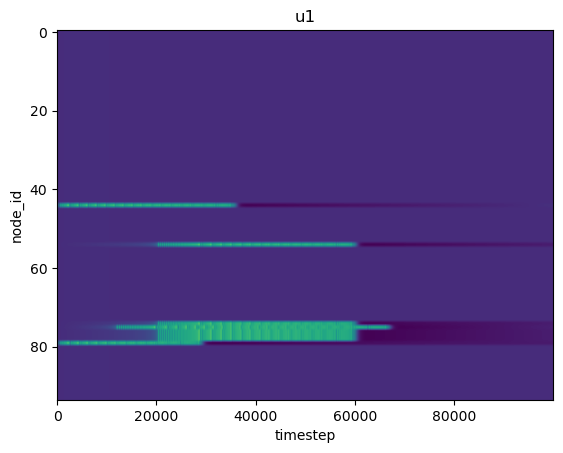

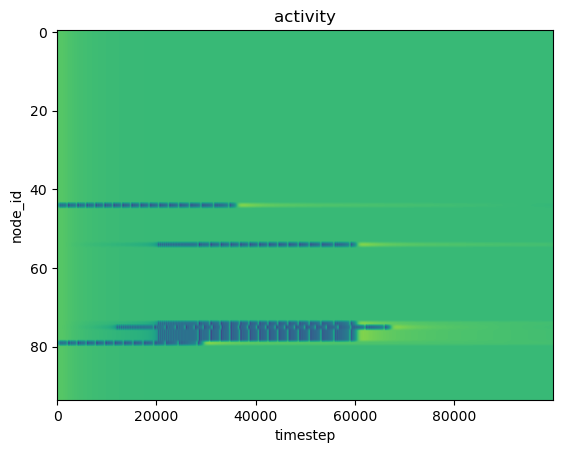

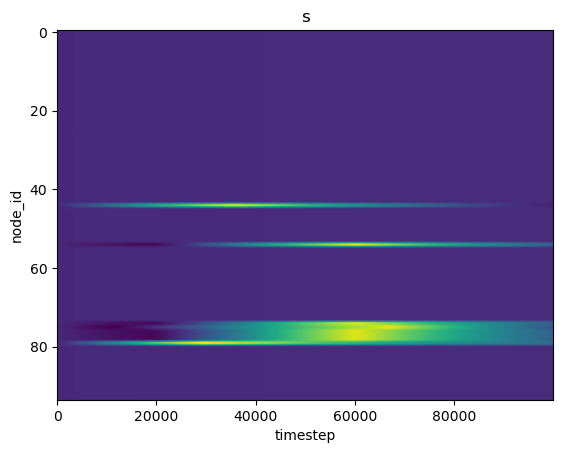

In [10]:
# raw data is a list (number of monitors, 1 if only raw monitors)
# raw_data[mon_id] is a tuple (0 for timestamps, 1 for states)
# raw_data[mon_id][1] is an array of shape (tsteps,n_var_of_interest,n_regions,1)

raw_data[0][1].shape
u1 = raw_data[0][1][:,0,:,0].T      # or epileptor x1 (fast)
activity= raw_data[0][1][:,1,:,0].T # or epileptor x2-x1 (seizure like events)
s= raw_data[0][1][:,2,:,0].T        # or epileptor z (permittivity driving the ictal states)

plt.title('u1')
plt.imshow(u1,aspect='auto')
plt.xlabel('timestep')
plt.ylabel('node_id')
plt.show()

plt.title('activity')
plt.imshow(activity,aspect='auto')
plt.xlabel('timestep')
plt.ylabel('node_id')
plt.show()

plt.title('s')
plt.imshow(s,aspect='auto')
plt.xlabel('timestep')
plt.ylabel('node_id')
plt.show()


## Downscaling From High Resolution To Low Resolution

In [11]:
from scipy.sparse import load_npz

utils_dir   = "example/utils_py"
region_names = list(np.genfromtxt(utils_dir + f"/fs_default_HC.txt", usecols=1, dtype=str))

rm = np.genfromtxt(sub_dir/"Diffusion"/"vert2vert_region_mapping_Resliced.txt")

n_regions=len(region_names)

weight_matrix=np.zeros((n_regions,n_regions))
gdist_matrix=np.zeros((n_regions,n_regions))

v2v_weights = load_npz(sub_dir/"Diffusion"/"vert2vert_weights_15M.npz")
v2v_gdist   = load_npz(sub_dir/"Diffusion"/"vert2vert_gdist_mat.npz")


print('new weight_matrix shape:' ,weight_matrix.shape)
from_nodes, to_nodes = v2v_weights.nonzero()
weights = v2v_weights.data
import tqdm
# Iterate through connections
for f, t, w in tqdm.tqdm(zip(from_nodes, to_nodes, weights)):
    
    weight_matrix[int(rm[f]),int(rm[t])]+=w


new weight_matrix shape: (94, 94)


19236230it [00:17, 1106135.50it/s]


In [12]:
v2v_lengths = load_npz(sub_dir/"Diffusion"/"vert2vert_lengths_15M.npz")
length_matrix=np.zeros((n_regions,n_regions))
counts=np.zeros((n_regions,n_regions))
print('new length_matrix shape:' ,length_matrix.shape)
from_nodes, to_nodes = v2v_lengths.nonzero()
lengths = v2v_lengths.data

# Iterate through connections
for f, t, l in tqdm.tqdm(zip(from_nodes, to_nodes, lengths)):
    
    length_matrix[int(rm[f]),int(rm[t])]+=l
    counts[int(rm[f]),int(rm[t])]+=1
mask = counts > 0
length_matrix[mask] /= counts[mask]


new length_matrix shape: (94, 94)


19236230it [00:25, 764591.74it/s]


In [ ]:
v2v_gdists = load_npz(sub_dir/"Diffusion"/"vert2vert_gdist_mat.npz")
gdist_matrix=np.zeros((n_regions,n_regions))
counts=np.zeros((n_regions,n_regions))
print('new gdist_matrix shape:' ,gdist_matrix.shape)
from_nodes, to_nodes = v2v_gdists.nonzero()
dists = v2v_gdists.data

# Iterate through connections
for f, t, d in tqdm.tqdm(zip(from_nodes, to_nodes, dists)):
    
    gdist_matrix[int(rm[f]),int(rm[t])]+=d
    counts[int(rm[f]),int(rm[t])]+=1
    
mask = counts > 0
gdist_matrix[mask] /= counts[mask]


new gdist_matrix shape: (94, 94)


193388839it [04:02, 793815.29it/s]

In [ ]:
np.save('weight_lr',weight_matrix)
np.save('length_lr',length_matrix)
np.save('dist_lr',gdist_matrix)

In [ ]:
from nibabel.freesurfer.io import read_geometry, read_morph_data
sub = "100206"
lh_v,lh_t, vol_info = read_geometry(sub_dir/sub/'surf'/'lh.hc_dg_cort_mid', read_metadata=True)
lh_v += vol_info['cras']
rh_v,rh_t, vol_info = read_geometry(sub_dir/sub/'surf'/'rh.hc_dg_cort_mid', read_metadata=True)
rh_v += vol_info['cras']
v = np.concatenate((lh_v,rh_v))
t = np.concatenate((lh_t, rh_t+lh_v.shape[0]))
n_vert=v.shape[0]

In [ ]:
# get vertex volumes [SURFACE AREAS! in the original code, they are used to scale the geodesic distance matrix]
vertex_volumes = np.concatenate((read_morph_data(sub_dir/sub/'surf'/"lh.hc_dg_cort.vertex_volume"),
                                read_morph_data(sub_dir/sub/'surf'/"rh.hc_dg_cort.vertex_volume"),
                                np.load(sub_dir/sub/'mri'/"aseg_subcort_numbered_vox.vertex_volume.npz")['vertex_volume']
                                ))

In [ ]:
n_vert

337981

In [ ]:
import nibabel as nib
aseg_numbered_img  = nib.load(str(sub_dir/sub/"mri"/"aseg_subcort_numbered_vox.nii.gz"))
affine = aseg_numbered_img.affine
data_numbered =  aseg_numbered_img.get_fdata().astype(int)
mask = np.ones(rm.shape[0], dtype=bool) #using all regions
data_numbered_mask = np.where(np.isin(data_numbered, np.where(mask[n_vert:])[0]+1)) # +1 because 0 is background

vox_coord   = np.vstack(data_numbered_mask)
vox_coord_1 = np.vstack((vox_coord, np.ones((1,vox_coord.shape[1]))))
subcort_ras_coord = affine.dot(vox_coord_1)[:3,:].T

In [ ]:
subcort_ras_coord.shape

(97509, 3)

In [ ]:
v_tot=np.concatenate([v,subcort_ras_coord])
print(subcort_ras_coord.shape)
print(v.shape)
print(v.shape[0]+subcort_ras_coord.shape[0])
print(v_tot.shape)
print(rm.shape)

(97509, 3)
(337981, 3)
435490
(435490, 3)
(435490,)


In [ ]:
region_ids=np.unique(rm)
centers=np.zeros((region_ids.shape[0],3))
print(centers.shape)
for id in region_ids:
    # print(id)
    mask=rm==id
    # print(v_tot[mask,:].shape)
    center=np.mean(v_tot[mask,:],axis=0)
    # print(center)
    centers[int(id),:]=center

np.save('centers_lr.npz',centers)

(94, 3)


In [ ]:
import plotly.io as pio
import plotly.graph_objs as go


filename='centers_lr.html'
x=centers[:,0]
y=centers[:,1]
z=centers[:,2]

# # Normalize the values to the range [0, 1] to apply the colormap
# norm = (vals - np.min(vals)) / (np.max(vals) - np.min(vals))

# Create a Plotly 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=5,
        color='red',               # Assign colors based on the 'values' array
        colorscale='Magma',        # Use the Viridis colormap in Plotly
        # colorscale='Viridis',        # Use the Viridis colormap in Plotly
        colorbar=dict(title='Value') # Add a colorbar
    )
)])


fig.update_layout(
    scene = dict(
        xaxis = dict(visible=False),
        yaxis = dict(visible=False),
        zaxis =dict(visible=False),
        # bgcolor=('#7B9E87')
        bgcolor=('white')
        )
    )


# Save the plot as an HTML file
pio.write_html(fig, file=filename, auto_open=True)


In [ ]:
# example, studying the right hippocampus CA1 
id=region_names.index('ctx-rh-CA1')
ca1_center=centers[id,:]
ca1_weights=weight_matrix[id,:]
print(region_names[np.argsort(ca1_weights)[-1]])
ca1_distances=length_matrix[id,:]
print(ca1_distances[region_names.index('ctx-rh-entorhinal')])
ca1_gdists=gdist_matrix[id,:]
print(ca1_gdists[region_names.index('ctx-rh-entorhinal')])


ctx-rh-CA1
18.260667744000028
8.817754179082586


## Visualizing the connectivity

In [ ]:
import matplotlib
import numpy as np

from mne_connectivity.viz import plot_connectivity_circle
from scipy.sparse import csr_matrix
from scipy.sparse import data, save_npz, load_npz
from pathlib import  Path

In [ ]:
sub_dir = Path("example/TVB/100206/T1w")
v2v_weights = load_npz(sub_dir/"Diffusion"/"vert2vert_weights_15M.npz")


utils_dir   = "example/utils_py"
rm = np.genfromtxt(sub_dir/"Diffusion"/"vert2vert_region_mapping_Resliced.txt")
region_names = list(np.genfromtxt(utils_dir + f"/fs_default_HC.txt", usecols=1, dtype=str))

n_regions=len(region_names)

weight_matrix=np.zeros((n_regions,n_regions))


ctx-lh-bankssts
ctx-lh-caudalanteriorcingulate
ctx-lh-caudalmiddlefrontal
ctx-lh-cuneus
ctx-lh-entorhinal
ctx-lh-fusiform
ctx-lh-inferiorparietal
ctx-lh-inferiortemporal
ctx-lh-isthmuscingulate
ctx-lh-lateraloccipital
ctx-lh-lateralorbitofrontal
ctx-lh-lingual
ctx-lh-medialorbitofrontal
ctx-lh-middletemporal
ctx-lh-parahippocampal
ctx-lh-paracentral
ctx-lh-parsopercularis
ctx-lh-parsorbitalis
ctx-lh-parstriangularis
ctx-lh-pericalcarine
ctx-lh-postcentral
ctx-lh-posteriorcingulate
ctx-lh-precentral
ctx-lh-precuneus
ctx-lh-rostralanteriorcingulate
ctx-lh-rostralmiddlefrontal
ctx-lh-superiorfrontal
ctx-lh-superiorparietal
ctx-lh-superiortemporal
ctx-lh-supramarginal
ctx-lh-frontalpole
ctx-lh-temporalpole
ctx-lh-transversetemporal
ctx-lh-insula
ctx-lh-Subiculum
ctx-lh-CA1
ctx-lh-CA2
ctx-lh-CA3
ctx-lh-CA4
ctx-lh-Dentate-gyrus
ctx-rh-bankssts
ctx-rh-caudalanteriorcingulate
ctx-rh-caudalmiddlefrontal
ctx-rh-cuneus
ctx-rh-entorhinal
ctx-rh-fusiform
ctx-rh-inferiorparietal
ctx-rh-inferiortempo

In [ ]:
rh_regions_name=[]
lh_regions_name=[]
sub_regions_name=[]
for name in region_names:
    if name.startswith('ctx-rh'):
        rh_regions_name.append(name.tolist())
    elif name.startswith('ctx-lh'):
        lh_regions_name.append(name.tolist())
    else:
        sub_regions_name.append(name.tolist())
    # print(name)

In [ ]:
print('new weight_matrix shape:' ,weight_matrix.shape)
from_nodes, to_nodes = v2v_weights.nonzero()
weights = v2v_weights.data
import tqdm
# Iterate through connections
for f, t, w in tqdm.tqdm(zip(from_nodes, to_nodes, weights)):
    
    weight_matrix[int(rm[f]),int(rm[t])]+=w


new weight_matrix shape: (94, 94)


19236230it [00:14, 1315381.30it/s]


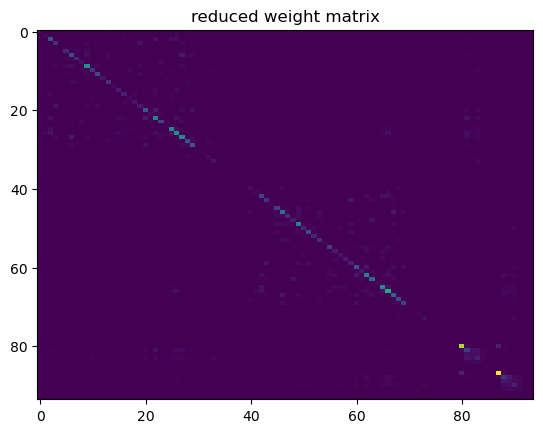

In [ ]:
import matplotlib.pyplot as plt
plt.title('reduced weight matrix')
plt.imshow(weight_matrix,aspect='auto')
plt.show()

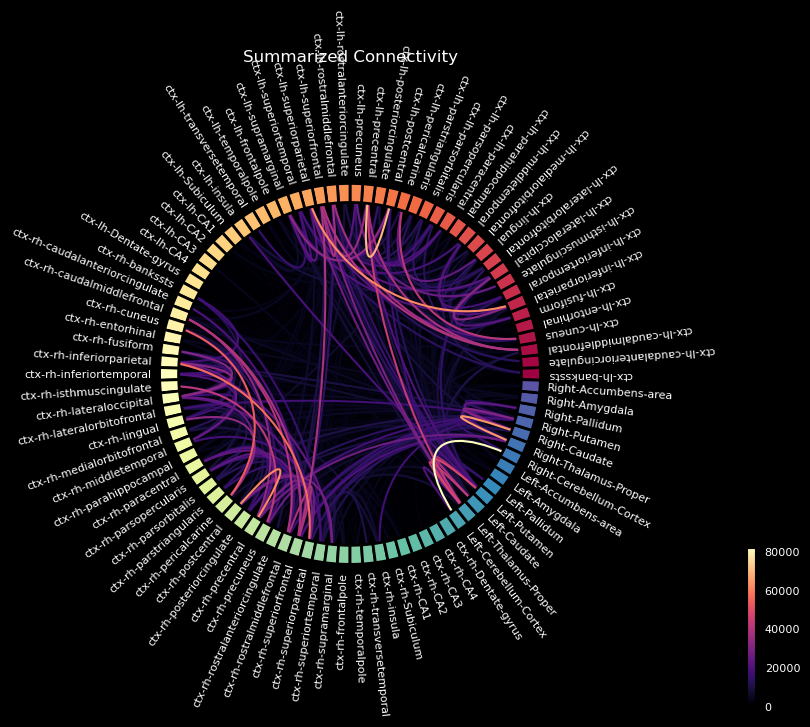

(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'Summarized Connectivity'}>)

In [ ]:

# Plot
plot_connectivity_circle(weight_matrix, region_names,
                         title='Summarized Connectivity',
                         colormap='magma')


## Trying to properly order the connectivity circle

In [ ]:
#assigning each of the 94 regions a macro brain area
region_class_dict = {
    # Left hemisphere - cortical
    'ctx-rh-temporalpole': 'Temporal',
    'ctx-rh-entorhinal': 'Temporal',
    'ctx-rh-transversetemporal': 'Temporal',
    'ctx-rh-fusiform': 'Temporal',
    'ctx-rh-bankssts': 'Temporal',
    'ctx-rh-inferiortemporal': 'Temporal',
    'ctx-rh-middletemporal': 'Temporal',
    'ctx-rh-superiortemporal': 'Temporal',
    'ctx-rh-precuneus': 'Parietal',
    'ctx-rh-postcentral': 'Parietal',
    'ctx-rh-supramarginal': 'Parietal',
    'ctx-rh-inferiorparietal': 'Parietal',
    'ctx-rh-superiorparietal': 'Parietal',
    'ctx-rh-frontalpole': 'Frontal',
    'ctx-rh-paracentral': 'Frontal',
    'ctx-rh-precentral': 'Frontal',
    'ctx-rh-medialorbitofrontal': 'Frontal',
    'ctx-rh-lateralorbitofrontal': 'Frontal',
    'ctx-rh-parstriangularis': 'Frontal',
    'ctx-rh-parsorbitalis': 'Frontal',
    'ctx-rh-parsopercularis': 'Frontal',
    'ctx-rh-caudalmiddlefrontal': 'Frontal',
    'ctx-rh-rostralmiddlefrontal': 'Frontal',
    'ctx-rh-superiorfrontal': 'Frontal',
    'ctx-lh-superiorfrontal': 'Frontal',
    'ctx-lh-rostralmiddlefrontal': 'Frontal',
    'ctx-lh-caudalmiddlefrontal': 'Frontal',
    'ctx-lh-parsopercularis': 'Frontal',
    'ctx-lh-parsorbitalis': 'Frontal',
    'ctx-lh-parstriangularis': 'Frontal',
    'ctx-lh-lateralorbitofrontal': 'Frontal',
    'ctx-lh-medialorbitofrontal': 'Frontal',
    'ctx-lh-precentral': 'Frontal',
    'ctx-lh-paracentral': 'Frontal',
    'ctx-lh-frontalpole': 'Frontal',
    'ctx-lh-superiorparietal': 'Parietal',
    'ctx-lh-inferiorparietal': 'Parietal',
    'ctx-lh-supramarginal': 'Parietal',
    'ctx-lh-postcentral': 'Parietal',
    'ctx-lh-precuneus': 'Parietal',
    'ctx-lh-superiortemporal': 'Temporal',
    'ctx-lh-middletemporal': 'Temporal',
    'ctx-lh-inferiortemporal': 'Temporal',
    'ctx-lh-bankssts': 'Temporal',
    'ctx-lh-fusiform': 'Temporal',
    'ctx-lh-transversetemporal': 'Temporal',
    'ctx-lh-entorhinal': 'Temporal',
    'ctx-lh-temporalpole': 'Temporal',
    'ctx-lh-parahippocampal': 'Temporal',
    'ctx-lh-lateraloccipital': 'Occipital',
    'ctx-lh-lingual': 'Occipital',
    'ctx-lh-cuneus': 'Occipital',
    'ctx-lh-pericalcarine': 'Occipital',
    'ctx-lh-rostralanteriorcingulate': 'Limbic',
    'ctx-lh-posteriorcingulate': 'Limbic',
    'ctx-lh-caudalanteriorcingulate': 'Limbic',
    'ctx-lh-isthmuscingulate': 'Limbic',
    'ctx-lh-Subiculum': 'Limbic',
    'ctx-lh-CA1': 'Limbic',
    'ctx-lh-CA2': 'Limbic',
    'ctx-lh-CA3': 'Limbic',
    'ctx-lh-CA4': 'Limbic',
    'ctx-lh-Dentate-gyrus': 'Limbic',
    'ctx-lh-insula': 'Insular',

    # Subcortical and cerebellar
    'Left-Amygdala': 'Limbic',
    'Left-Cerebellum-Cortex': 'Cerebellum',
    'Left-Thalamus-Proper': 'Subcortical',
    'Left-Caudate': 'Subcortical',
    'Left-Putamen': 'Subcortical',
    'Left-Pallidum': 'Subcortical',
    'Left-Accumbens-area': 'Subcortical',
    'Right-Accumbens-area': 'Subcortical',
    'Right-Pallidum': 'Subcortical',
    'Right-Putamen': 'Subcortical',
    'Right-Caudate': 'Subcortical',
    'Right-Thalamus-Proper': 'Subcortical',
    'Right-Cerebellum-Cortex': 'Cerebellum',
    'Right-Amygdala': 'Limbic',

    'ctx-rh-insula': 'Insular',
    'ctx-rh-Dentate-gyrus': 'Limbic',
    'ctx-rh-CA4': 'Limbic',
    'ctx-rh-CA3': 'Limbic',
    'ctx-rh-CA2': 'Limbic',
    'ctx-rh-CA1': 'Limbic',
    'ctx-rh-Subiculum': 'Limbic',
    'ctx-rh-isthmuscingulate': 'Limbic',
    'ctx-rh-caudalanteriorcingulate': 'Limbic',
    'ctx-rh-posteriorcingulate': 'Limbic',
    'ctx-rh-rostralanteriorcingulate': 'Limbic',
    'ctx-rh-pericalcarine': 'Occipital',
    'ctx-rh-cuneus': 'Occipital',
    'ctx-rh-lingual': 'Occipital',
    'ctx-rh-lateraloccipital': 'Occipital',
    'ctx-rh-parahippocampal': 'Temporal',
    
   
}


In [ ]:
map=np.zeros(len(region_class_dict.keys())).astype(np.uint16)
print(map.shape)
print(region_class_dict.keys())
region_names_plot=[]
for i,key in enumerate(region_class_dict):
    map[i]=region_names.index(key)
    region_names_plot.append(key)

mapped_weights = weight_matrix[np.ix_(map, map)]

(94,)
dict_keys(['ctx-rh-temporalpole', 'ctx-rh-entorhinal', 'ctx-rh-transversetemporal', 'ctx-rh-fusiform', 'ctx-rh-bankssts', 'ctx-rh-inferiortemporal', 'ctx-rh-middletemporal', 'ctx-rh-superiortemporal', 'ctx-rh-precuneus', 'ctx-rh-postcentral', 'ctx-rh-supramarginal', 'ctx-rh-inferiorparietal', 'ctx-rh-superiorparietal', 'ctx-rh-frontalpole', 'ctx-rh-paracentral', 'ctx-rh-precentral', 'ctx-rh-medialorbitofrontal', 'ctx-rh-lateralorbitofrontal', 'ctx-rh-parstriangularis', 'ctx-rh-parsorbitalis', 'ctx-rh-parsopercularis', 'ctx-rh-caudalmiddlefrontal', 'ctx-rh-rostralmiddlefrontal', 'ctx-rh-superiorfrontal', 'ctx-lh-superiorfrontal', 'ctx-lh-rostralmiddlefrontal', 'ctx-lh-caudalmiddlefrontal', 'ctx-lh-parsopercularis', 'ctx-lh-parsorbitalis', 'ctx-lh-parstriangularis', 'ctx-lh-lateralorbitofrontal', 'ctx-lh-medialorbitofrontal', 'ctx-lh-precentral', 'ctx-lh-paracentral', 'ctx-lh-frontalpole', 'ctx-lh-superiorparietal', 'ctx-lh-inferiorparietal', 'ctx-lh-supramarginal', 'ctx-lh-postcen

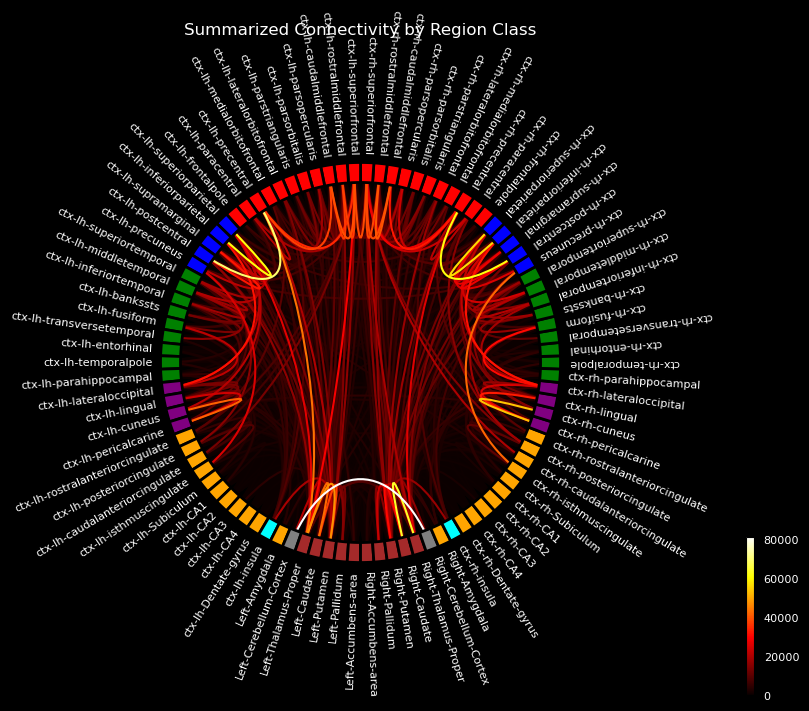

(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'Summarized Connectivity by Region Class'}>)

In [ ]:


# Color Coding the brain areas
classification_colors = {
    'Frontal': 'red',
    'Parietal': 'blue',
    'Temporal': 'green',
    'Occipital': 'purple',
    'Limbic': 'orange',
    'Insular': 'cyan',
    'Subcortical': 'brown',
    'Cerebellum': 'gray'
}


# Generate node colors based on classification
node_colors = [classification_colors[region_class_dict[r]] for r in region_names_plot]

# Plot
plot_connectivity_circle(mapped_weights, region_names_plot,
                         node_colors=node_colors,
                        #  n_lines=30,
                         title='Summarized Connectivity by Region Class',
                         colormap='hot',
                         facecolor='black',
                         textcolor='white')
# plot_connectivity_circle(weight_matrix, region_names,
#                          node_colors=node_colors,
#                          title='Summarized Connectivity by Region Class',
#                          colormap='hot',
#                          facecolor='white',
#                          textcolor='black')


ctx-rh-CA1 83


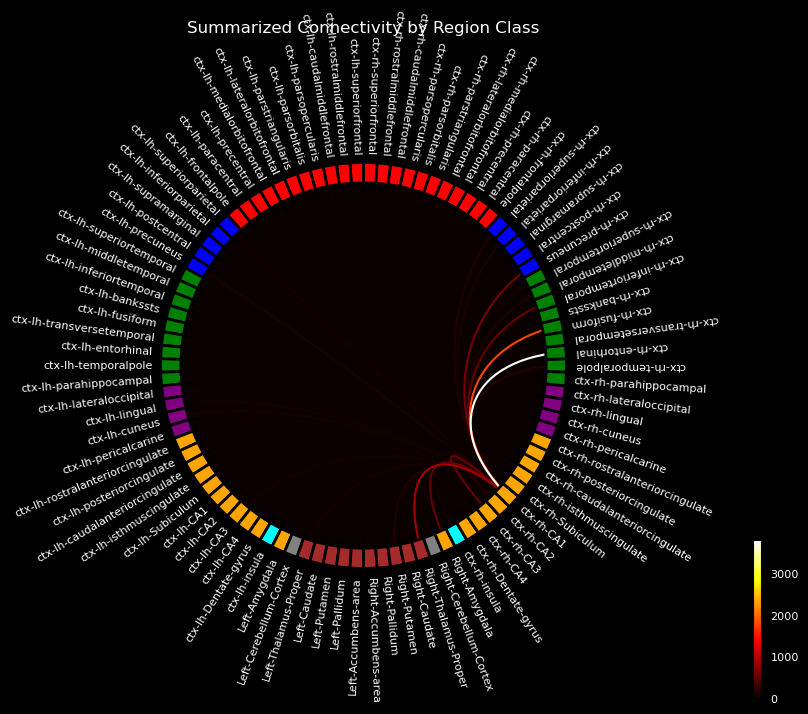

(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'Summarized Connectivity by Region Class'}>)

In [ ]:
# Extracting single regions connectivities

region_name_single='ctx-rh-CA1'
region_name_single_id=region_names_plot.index(region_name_single)
print(region_name_single,region_name_single_id)
mapped_weights_single=np.zeros_like(mapped_weights)
mapped_weights_single[region_name_single_id,:]=mapped_weights[region_name_single_id,:]



# Generate node colors based on classification
node_colors = [classification_colors[region_class_dict[r]] for r in region_names_plot]

# Plot
plot_connectivity_circle(mapped_weights_single, region_names_plot,
                         node_colors=node_colors,
                        #  n_lines=30,
                         title='Summarized Connectivity by Region Class',
                         colormap='hot',
                         facecolor='black',
                         textcolor='white')
